# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
#!pip install tensorflow[and-cuda]==2.19.0 scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt                                                                  # Importing matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules.
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build the CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in the model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix                                                     # Importing confusion_matrix to plot the confusion matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

# To oversample data.
from imblearn.over_sampling import SMOTE

# Importing cv2_imshow from google.patches to display images
#from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models.
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 0
2.20.0


In [4]:
# 1. Set Python random seed.
random.seed(812)

# 2. Set NumPy random seed.
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend).
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU).
tf.config.experimental.enable_op_determinism()

# **Data Overview**


## Loading the data

In [5]:
images = np.load('images.npy') # Loading the images.

labels = pd.read_csv('labels.csv') # Loading the labels.

In [6]:
print(images.shape) # Shape of the images.
print(labels.shape) # Shape of the labels.

(4125, 200, 200, 3)
(4125, 1)


* The dataset has 4125 color images, with 200 pixels wide and 200 pixels tall.
* There are no missing labels.

# **Exploratory Data Analysis**

* It is important to note that although the "business" objective of the model is to identify people **not wearing helmet** (safety risk), the labels in the dataset for the target class 1 is for **wearing helmet**.  Is important to keep this in mind to select the correct metrics for the model.

#### Identify format (RBG vs BGR) of images

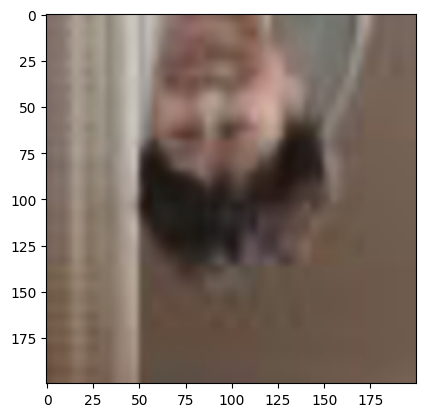

In [7]:
# Display images[0] with MatplotLib.
plt.imshow(images[100])
plt.show()

* From the sample image, format of the images in the dataset is **RGB**.

### Ploting random images from each of the classes and print their corresponding labels.

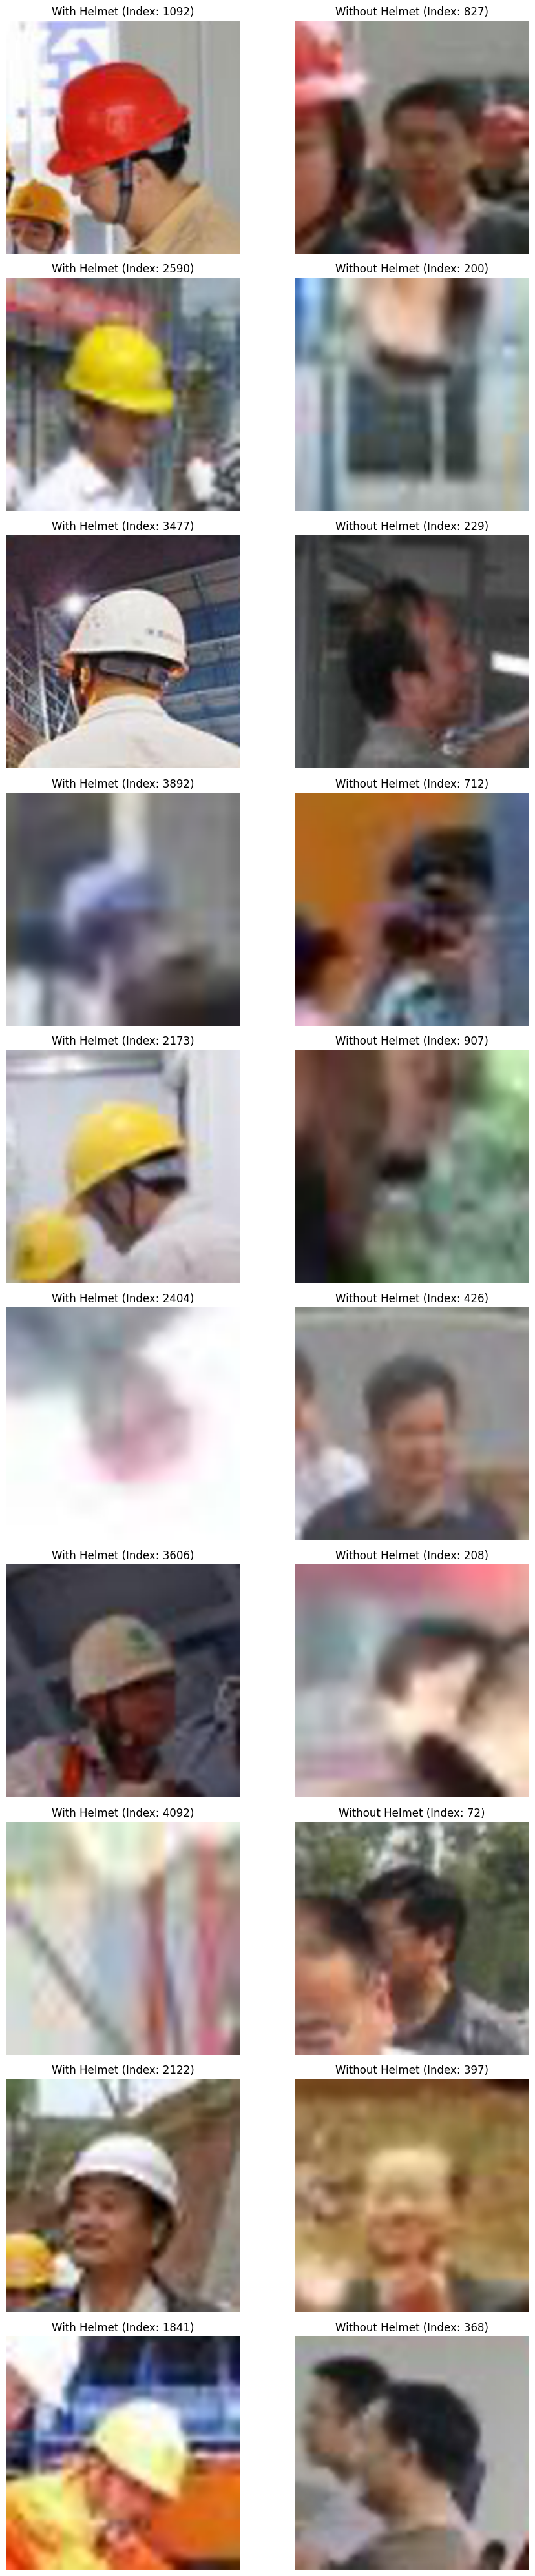

In [8]:
# Get indices for 'With Helmet' (label 1) and 'Without Helmet' (label 0).
helmet_indices = labels[labels.iloc[:, 0] == 1].index.tolist()
no_helmet_indices = labels[labels.iloc[:, 0] == 0].index.tolist()

# Select 10 random indices from each class.
num_samples_to_plot = 10
random_helmet_idxs = random.sample(helmet_indices, num_samples_to_plot)
random_no_helmet_idxs = random.sample(no_helmet_indices, num_samples_to_plot)

fig, axes = plt.subplots(num_samples_to_plot, 2, figsize=(10, 4 * num_samples_to_plot))

for i in range(num_samples_to_plot):
    # Plot 'With Helmet' images.
    axes[i][0].imshow(images[random_helmet_idxs[i]])
    axes[i][0].set_title(f"With Helmet (Index: {random_helmet_idxs[i]})")
    axes[i][0].axis("off")

    # Plot 'Without Helmet' images.
    axes[i][1].imshow(images[random_no_helmet_idxs[i]])
    axes[i][1].set_title(f"Without Helmet (Index: {random_no_helmet_idxs[i]})")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

* From the sample, is easy to see that the dataset has images that already have been pre-processed, as it shows some flipped images, blured ones and other types of image processing.

## Checking for class imbalance


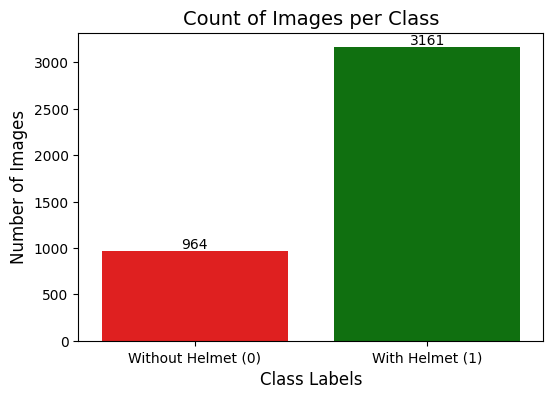

In [9]:
# Create a count plot.
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars.
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels.
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels.

# Show plot.
plt.show()

* There is a high imbalance biased toward the positive class (1 - With Helmet): 76.6% for class 1, 23.6% for class 0.
* As the dataset is imbalanced, it is expected that accuracy will not be a good metric.

# **Data Preprocessing**

### Splitting the dataset



In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.3, random_state=42,stratify=labels) # Defining the test_size for 70/30.
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp) # Defining the test_size of 50/50 for validation and test sets.

In [11]:
print(X_train.shape,y_train.shape) # Shape of the train data.
print(X_val.shape,y_val.shape) # Shape of the validation data.
print(X_test.shape,y_test.shape) # Shape of the test data.

(2887, 200, 200, 3) (2887, 1)
(619, 200, 200, 3) (619, 1)
(619, 200, 200, 3) (619, 1)


### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [12]:
X_train_normalized = X_train.astype('float32')/255 # Normalizing the training images.
X_val_normalized = X_val.astype('float32')/255  # Normalizing the validation images.
X_test_normalized = X_test.astype('float32')/255   # Normalizing the test images.

### Creating a balanced training dataset using oversampling.

In [13]:
print("Before OverSampling, counts of label '1': {}".format((y_train.iloc[:, 0] == 1).sum()))
print("Before OverSampling, counts of label '0': {} \n".format((y_train.iloc[:, 0] == 0).sum()))

# Get original image dimensions.
img_height, img_width, img_channels = X_train_normalized.shape[1:]

# Flatten X_train_normalized for SMOTE.
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)

# Synthetic Minority Over Sampling Technique.
sm = SMOTE(sampling_strategy=1, k_neighbors=4, random_state=1)
X_train_o_flat, y_train_o = sm.fit_resample(X_train_flat, y_train)

# Reshape X_train_o_flat back to original image dimensions.
X_train_o = X_train_o_flat.reshape(X_train_o_flat.shape[0], img_height, img_width, img_channels)

# Convert y_train_o to a Pandas DataFrame for consistency with y_train.
y_train_o = pd.DataFrame(y_train_o, columns=y_train.columns)

print("After OverSampling, counts of label '1': {}".format((y_train_o.iloc[:, 0] == 1).sum()))
print("After OverSampling, counts of label '0': {} \n".format((y_train_o.iloc[:, 0] == 0).sum()))


print("After OverSampling, the shape of train_X: {}".format(X_train_o.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_o.shape))

Before OverSampling, counts of label '1': 2212
Before OverSampling, counts of label '0': 675 

After OverSampling, counts of label '1': 2212
After OverSampling, counts of label '0': 2212 

After OverSampling, the shape of train_X: (4424, 200, 200, 3)
After OverSampling, the shape of train_y: (4424, 1) 



### Visualizing Sample Images from the Oversampled Training Set

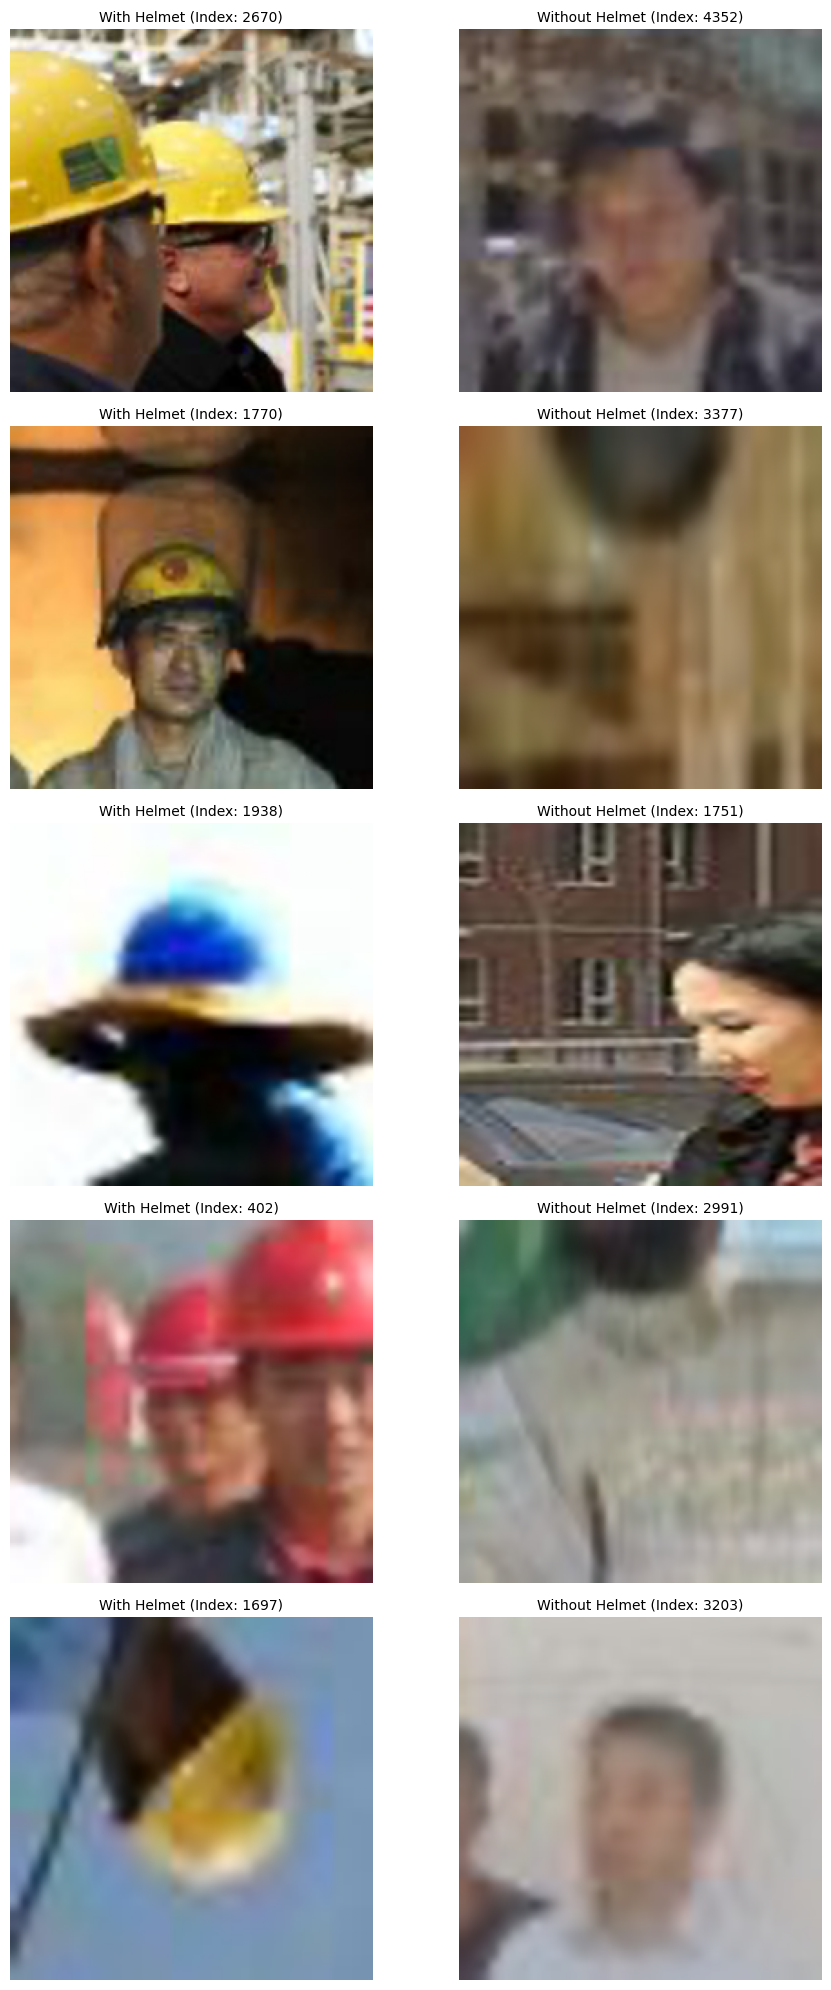

In [14]:
def plot_oversampled_images(X_oversampled, y_oversampled, num_samples_to_plot=5):
    """
    Plots a specified number of random images from each class ('With Helmet' and 'Without Helmet')
    from the oversampled training set.

    Args:
        X_oversampled (np.ndarray): The oversampled image data.
        y_oversampled (pd.DataFrame): The oversampled labels.
        num_samples_to_plot (int): The number of random samples to plot from each class.
    """
    # Get indices for 'With Helmet' (label 1) and 'Without Helmet' (label 0).
    helmet_indices = y_oversampled[y_oversampled.iloc[:, 0] == 1].index.tolist()
    no_helmet_indices = y_oversampled[y_oversampled.iloc[:, 0] == 0].index.tolist()

    # Select random indices from each class, ensuring we don't request more than available.
    num_helmet = min(num_samples_to_plot, len(helmet_indices))
    num_no_helmet = min(num_samples_to_plot, len(no_helmet_indices))

    random_helmet_idxs = random.sample(helmet_indices, num_helmet)
    random_no_helmet_idxs = random.sample(no_helmet_indices, num_no_helmet)

    fig, axes = plt.subplots(max(num_helmet, num_no_helmet), 2, figsize=(10, 4 * max(num_helmet, num_no_helmet)))

    # Handle cases where one class might have fewer samples than requested num_samples_to_plot.
    for i in range(max(num_helmet, num_no_helmet)):
        if i < num_helmet:
            # Plot 'With Helmet' images.
            axes[i][0].imshow(X_oversampled[random_helmet_idxs[i]])
            axes[i][0].set_title(f"With Helmet (Index: {random_helmet_idxs[i]})", fontsize=10)
            axes[i][0].axis("off")
        else:
            axes[i][0].axis("off") # Hide empty subplots if one class has fewer samples.

        if i < num_no_helmet:
            # Plot 'Without Helmet' images.
            axes[i][1].imshow(X_oversampled[random_no_helmet_idxs[i]])
            axes[i][1].set_title(f"Without Helmet (Index: {random_no_helmet_idxs[i]})", fontsize=10)
            axes[i][1].axis("off")
        else:
            axes[i][1].axis("off") # Hide empty subplots.

    plt.tight_layout()
    plt.show()

# Call the function to visualize 5 sample images from each class.
plot_oversampled_images(X_train_o, y_train_o, num_samples_to_plot=5)

# **Model Building**

**Model Objective:**
* Create an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets (label **1**).
- **Without Helmet:** Workers not wearing safety helmets (label **0**).

**Model's possible wrong predictions (confusion matrix):**

*  Predicts "Without Helmet" (0), but in reality the worker is wearing a helmet **(FN)**.

*  Predicts "With Helmet" (1), but in reality the worker or person is not wearing a safety helmet **(FP)**.

**Impact of wrong predictions:**

*  For False Negatives (FN) — Will require a quick visual confirmation, as worker is effectively wearing a safety helmet.

*  For False Positives (FP) — Would require removing and preventing the person or worker from entering the site, and provide a safety helmet as this person is a safety risk.

**Model Focus:**

* As False positives represent the highest risk, is important to convert them to True Negatives.

* Minimizing False Positives is crucial. This translates to prioritizing a model that has a high **Precision** score.

**General Model:**

*  For this project a basic convolutional neural network (CNN) will be created and then tuned.


## Utility Functions

In [15]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels.
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold.
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy.
    recall = recall_score(target, pred, average='macro')  # to compute Recall.
    precision = precision_score(target, pred, average='macro')  # to compute Precision.
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score.

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[1])

    return df_perf

In [16]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        cbar=False,
        xticklabels=['No Helmet', 'Helmet'],
        yticklabels=['No Helmet', 'Helmet'],
        ax=ax
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

## Model 1: Convolutional Neural Network (CNN) from Scratch.

Let's build a **CNN Model**.<br>

The model has 2 main parts:
1. **The Feature Extraction layers** which are comprised of convolutional and pooling layers.
2. **The Fully Connected classification layers for prediction.**<br><br>





In [17]:
# Initializing Model.
model_1 = Sequential()

# Convolutional layers.
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) 
model_1.add(MaxPooling2D((2, 2), padding='same'))
model_1.add(Conv2D(64, (3, 3), activation='relu', padding="same")) 
model_1.add(MaxPooling2D((2, 2), padding='same')) 
model_1.add(Conv2D(128, (3, 3), activation='relu', padding="same")) 

# Flatten and Dense layers.
model_1.add(Flatten())
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  

In [18]:
# Compile with Adam Optimizer.
opt = Adam(learning_rate=0.001)

In [19]:
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["Accuracy", "Recall", "Precision", "f1_score"]) # Including all metrics to have reliable results.

In [20]:
# Summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │     1,280,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,373,257 (5.24 MB)

 Trainable params: 1,373,257 (5.24 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=20, # Setting 20 as number of epochs for all models.
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=64, # Defining 64 as the batch size for all models.
            verbose=2
)

Epoch 1/20
46/46 - 8s - 181ms/step - Accuracy: 0.7800 - Precision: 0.7862 - Recall: 0.9792 - f1_score: 0.8676 - loss: 0.4748 - val_Accuracy: 0.8562 - val_Precision: 0.8459 - val_Recall: 0.9937 - val_f1_score: 0.8684 - val_loss: 0.3233
Epoch 2/20
46/46 - 7s - 158ms/step - Accuracy: 0.8919 - Precision: 0.9005 - Recall: 0.9656 - f1_score: 0.8676 - loss: 0.2975 - val_Accuracy: 0.8950 - val_Precision: 0.8942 - val_Recall: 0.9789 - val_f1_score: 0.8684 - val_loss: 0.2829
Epoch 3/20
46/46 - 7s - 156ms/step - Accuracy: 0.9151 - Precision: 0.9245 - Recall: 0.9684 - f1_score: 0.8676 - loss: 0.2582 - val_Accuracy: 0.8966 - val_Precision: 0.8929 - val_Recall: 0.9832 - val_f1_score: 0.8684 - val_loss: 0.3064
Epoch 4/20
46/46 - 7s - 156ms/step - Accuracy: 0.9276 - Precision: 0.9383 - Recall: 0.9693 - f1_score: 0.8676 - loss: 0.2458 - val_Accuracy: 0.8740 - val_Precision: 0.8642 - val_Recall: 0.9916 - val_f1_score: 0.8684 - val_loss: 0.3494
Epoch 5/20
46/46 - 7s - 157ms/step - Accuracy: 0.9176 - Prec

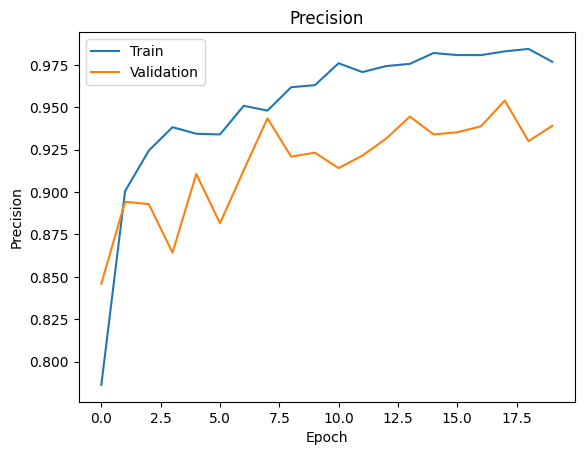

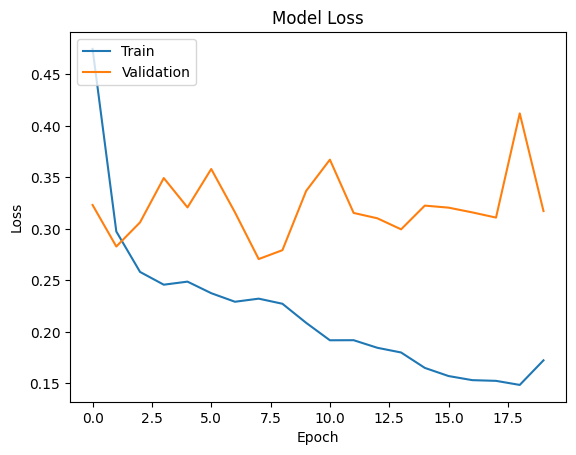

In [22]:
plt.plot(history_1.history['Precision']) #train metrics.
plt.plot(history_1.history['val_Precision']) #validation data metrics.
plt.title('Precision') #title for the plot.
plt.ylabel('Precision') #label for the y-axis.
plt.xlabel('Epoch') #label for the x-axis.
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# plot loss.
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [23]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.969519  0.961579   0.954177  0.957807


91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


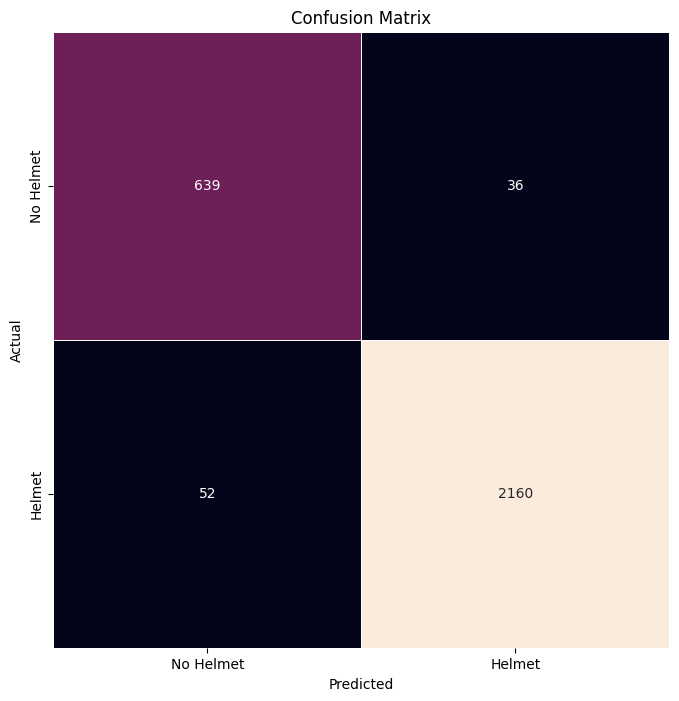

In [24]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [25]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.907916  0.869832   0.871636  0.870728


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


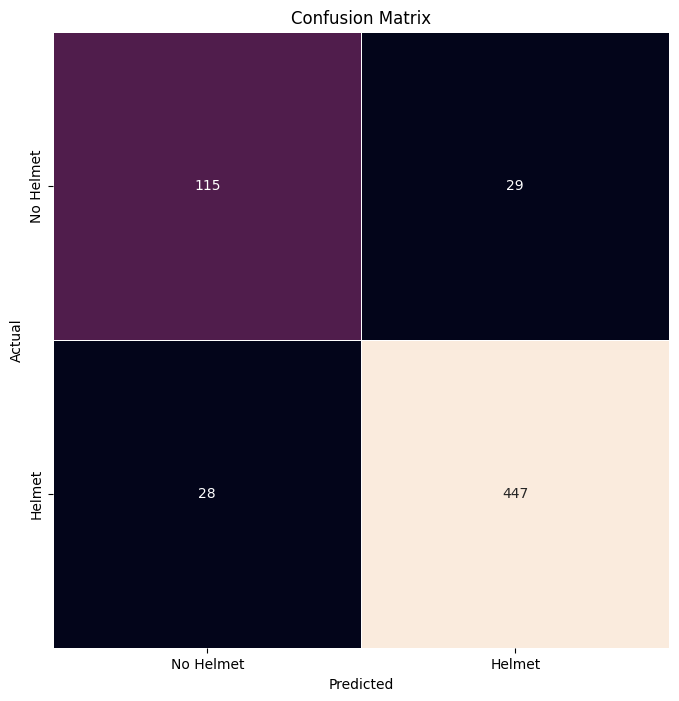

In [26]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

### Visualizing the predictions

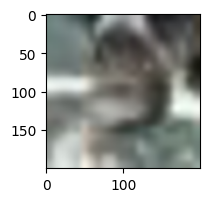

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Label: 0
True Label: label    0
Name: 840, dtype: int64


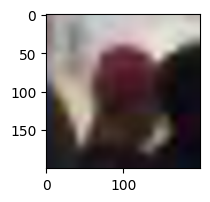

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Label: 0
True Label: label    1
Name: 1133, dtype: int64


In [27]:
# For index 12.
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_1.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[12]
print('True Label:', true_label)

# For index 33.
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_1.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 2: Transfer Learning with VGG-16 (Base)

- We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer; and will be using the oversampled dataset created previously with SMOTE.


In [28]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200, 200, 3)) # Setting the shape of the image the same as the dataset.
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them.
for layer in vgg_model.layers:
    layer.trainable = False

In [30]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above.
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer.
model_2.add(Flatten())

# Adding a dense output layer.
model_2.add(Dense(1, activation='sigmoid')) 

In [31]:
opt=Adam(learning_rate=0.001) 
# Compile model.
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["Accuracy", "Recall", "Precision", "f1_score"])

In [32]:
# Generating the summary of the model.
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [33]:
train_datagen = ImageDataGenerator()

In [34]:
# Epochs.
epochs = 20
# Batch size.
batch_size = 64

history_2 = model_2.fit(train_datagen.flow(X_train_o,y_train_o,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_o.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 57s 821ms/step - Accuracy: 0.6544 - Precision: 0.6563 - Recall: 0.6691 - f1_score: 0.6732 - loss: 0.6678 - val_Accuracy: 0.7916 - val_Precision: 0.8950 - val_Recall: 0.8253 - val_f1_score: 0.8684 - val_loss: 0.3739
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - Accuracy: 0.9062 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - f1_score: 0.0000e+00 - loss: 0.3144 - val_Accuracy: 0.7722 - val_Precision: 0.9349 - val_Recall: 0.7558 - val_f1_score: 0.8684 - val_loss: 0.4243
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 57s 822ms/step - Accuracy: 0.8491 - Precision: 0.8981 - Recall: 0.7925 - f1_score: 0.6732 - loss: 0.3485 - val_Accuracy: 0.7916 - val_Precision: 0.9391 - val_Recall: 0.7789 - val_f1_score: 0.8684 - val_loss: 0.3731
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - Accuracy: 0.9688 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - f1_score: 0.0000e+00 - loss: 0.1645 - val_Accuracy: 0.7916 - val_Precision: 0.9413 - val_Recall: 0.7768 - val_f1

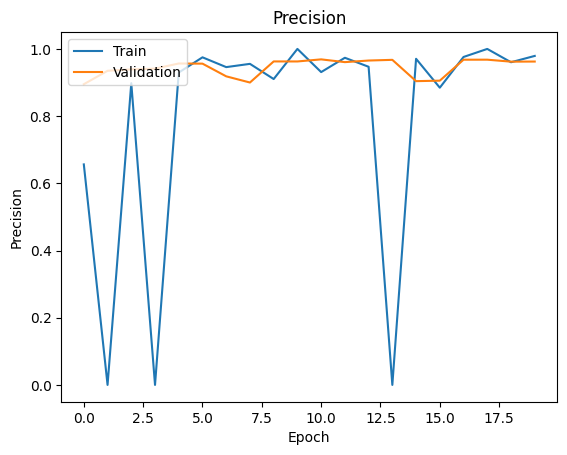

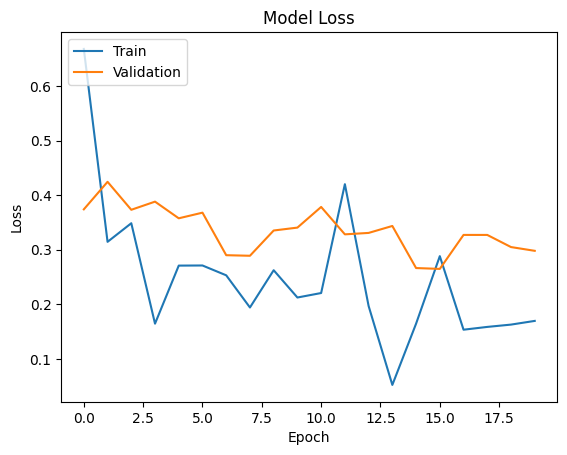

In [35]:
plt.plot(history_2.history['Precision']) #train metrics.
plt.plot(history_2.history['val_Precision']) #validation data metrics.
plt.title('Precision') #title for the plot.
plt.ylabel('Precision') #label for the y-axis.
plt.xlabel('Epoch') #label for the x-axis.
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# plot loss.
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [36]:
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 379ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.924489  0.942488   0.878746  0.903317


91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 380ms/step


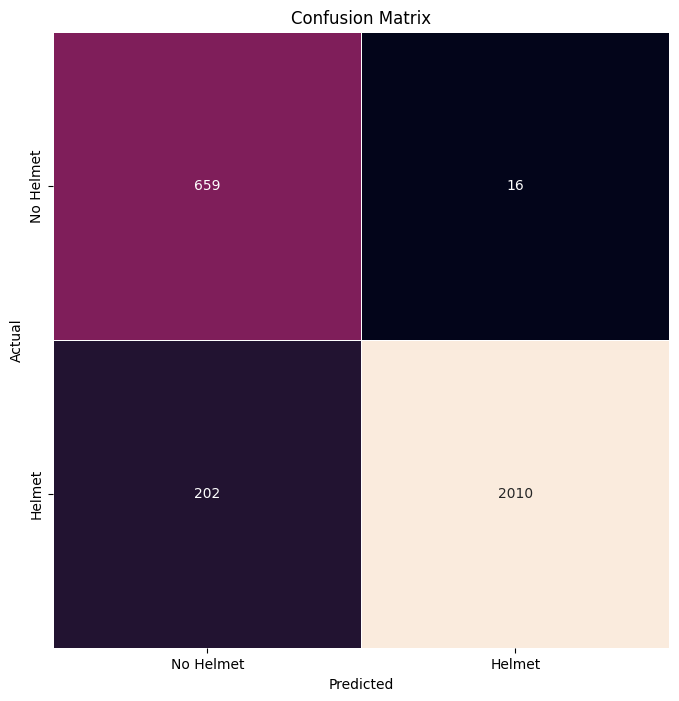

In [37]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [38]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 376ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.869144  0.876023   0.812827  0.834872


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 375ms/step


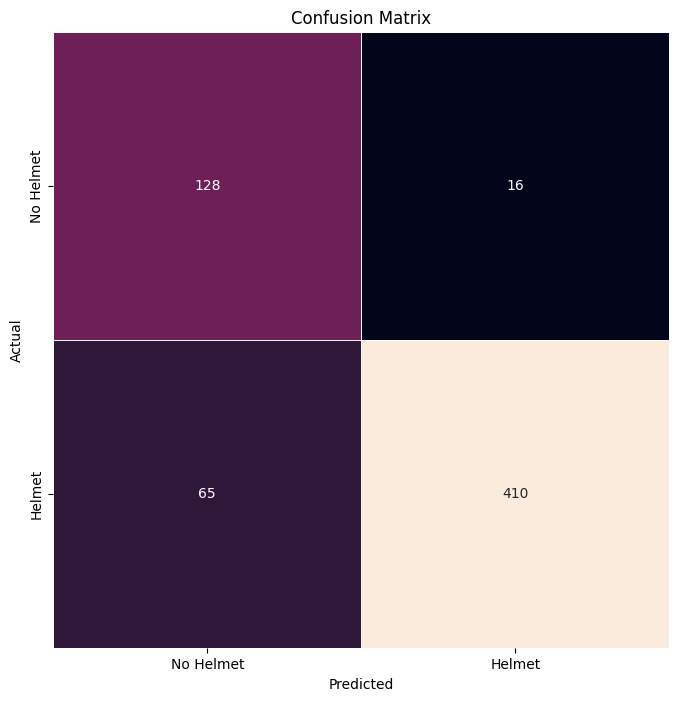

In [39]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

### Visualizing the predictions

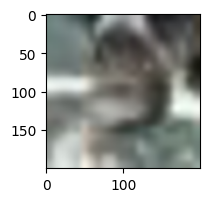

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Label: 0
True Label: label    0
Name: 840, dtype: int64


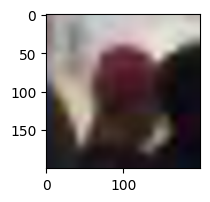

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label: 0
True Label: label    1
Name: 1133, dtype: int64


In [40]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_2.predict(X_val_normalized[12].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[12] 
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33]) 
plt.show()
prediction = model_2.predict(X_val_normalized[33].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





- We will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten layer and a Feed Forward Neural Network.


In [41]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above.
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer.
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu')) 
model_3.add(Dropout(rate=0.4)) 
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer.
model_3.add(Dense(1, activation='sigmoid'))

In [42]:
opt = Adam(learning_rate=0.001)

In [43]:
# Compile model.
model_3.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["Accuracy", "Recall", "Precision", "f1_score"])

In [44]:
# Generating the summary of the model.
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [45]:
history_3 = model_3.fit(train_datagen.flow(X_train_o,y_train_o,
                                       batch_size=64,
                                       seed=42,
                                       shuffle=False),
                    epochs=20,
                    steps_per_epoch=X_train_o.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 61s 874ms/step - Accuracy: 0.6376 - Precision: 0.6372 - Recall: 0.6260 - f1_score: 0.6632 - loss: 0.7204 - val_Accuracy: 0.6591 - val_Precision: 0.9286 - val_Recall: 0.6021 - val_f1_score: 0.8684 - val_loss: 0.5972
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - Accuracy: 0.7344 - Precision: 0.9444 - Recall: 0.6939 - f1_score: 0.8673 - loss: 0.5710 - val_Accuracy: 0.6478 - val_Precision: 0.9509 - val_Recall: 0.5705 - val_f1_score: 0.8684 - val_loss: 0.6176
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 57s 830ms/step - Accuracy: 0.7541 - Precision: 0.7891 - Recall: 0.6884 - f1_score: 0.6632 - loss: 0.4983 - val_Accuracy: 0.7415 - val_Precision: 0.9487 - val_Recall: 0.7011 - val_f1_score: 0.8684 - val_loss: 0.4763
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - Accuracy: 0.8125 - Precision: 0.9512 - Recall: 0.7959 - f1_score: 0.8673 - loss: 0.4160 - val_Accuracy: 0.7302 - val_Precision: 0.9477 - val_Recall: 0.6863 - val_f1_score: 0.8684 - val_los

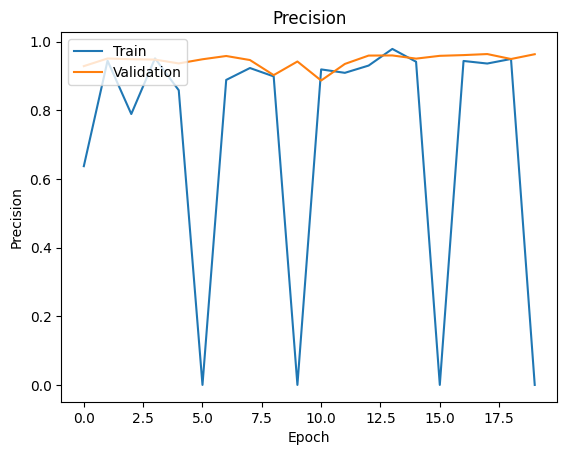

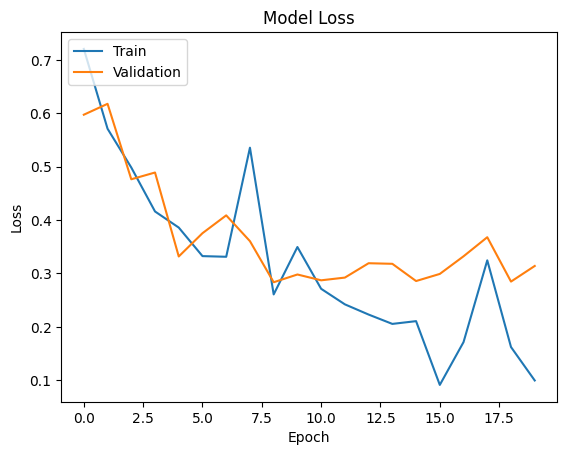

In [46]:
plt.plot(history_3.history['Precision']) #train metrics.
plt.plot(history_3.history['val_Precision']) #validation data metrics.
plt.title('Precision') #title for the plot.
plt.ylabel('Precision') #label for the y-axis.
plt.xlabel('Epoch') #label for the x-axis.
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# plot loss.
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [47]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.928646  0.945201   0.884178  0.908179


91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step


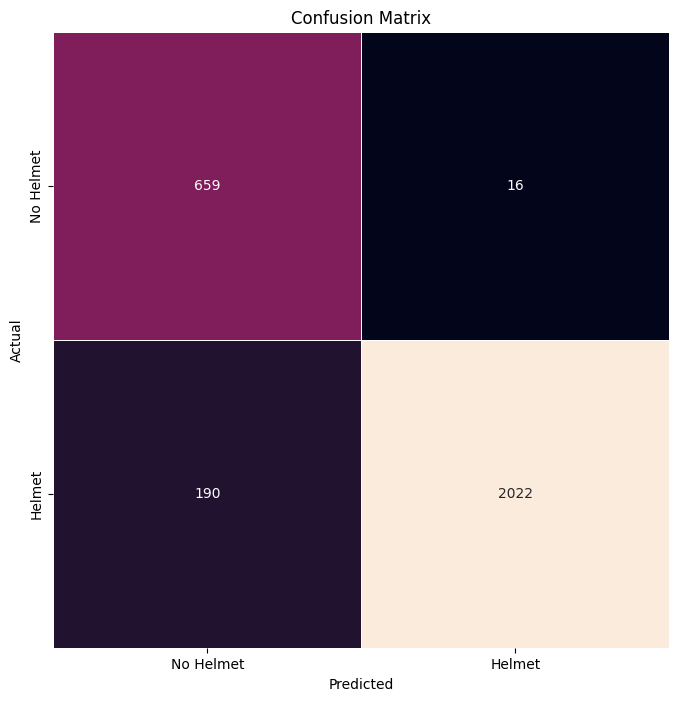

In [48]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [49]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 368ms/step
Validation performance metrics
   Accuracy   Recall  Precision  F1 Score
1  0.885299  0.88655   0.831378  0.852469


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 363ms/step


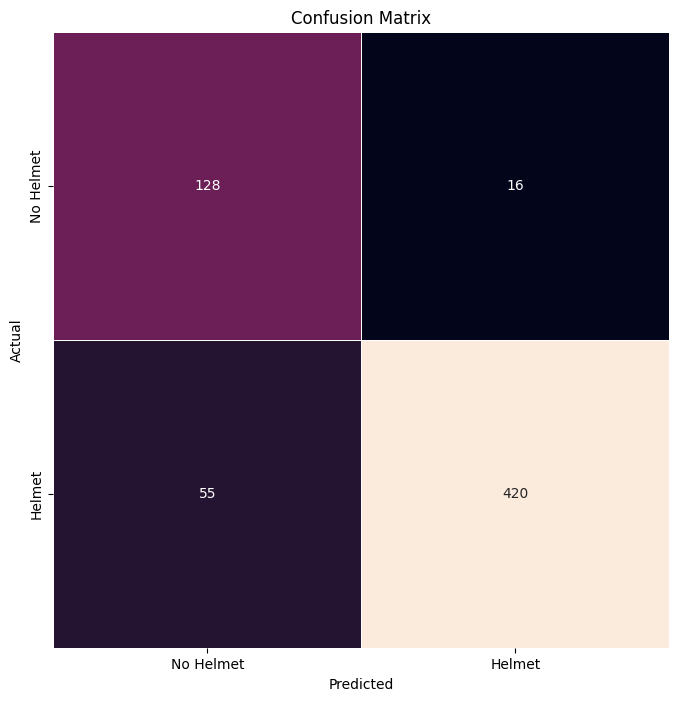

In [50]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

#### Visualizing the predictions

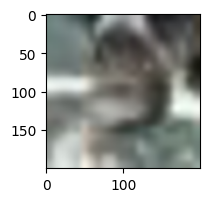

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Label: 0
True Label: label    0
Name: 840, dtype: int64


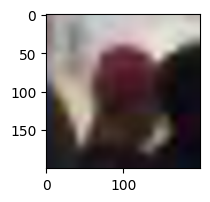

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Label: 0
True Label: label    1
Name: 1133, dtype: int64


In [51]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[12]) 
plt.show()
prediction = model_3.predict(X_val_normalized[12].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[12] 
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_3.predict(X_val_normalized[33].reshape(1,200,200,3)) 
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[33] 
print('True Label:', true_label)

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

* As we will be applying Data Augmentation to the oversampled dataset, it is expected the level of noise will increase significantly.

In [52]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above.
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer.
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu')) 
model_4.add(Dropout(rate=0.4)) 
model_4.add(Dense(32,activation='relu'))

# Adding a dense output layer.
model_4.add(Dense(1, activation='sigmoid')) 

In [53]:
opt=Adam(learning_rate=0.001)
# Compile model.
model_4.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["Accuracy", "Recall", "Precision", "f1_score"]) 

In [54]:
# Generating the summary of the model.
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [55]:
# Applying data augmentation.

train_datagen = ImageDataGenerator(
    rotation_range=20,        # Range for rotation.
    fill_mode='nearest',
    width_shift_range=0.20,     # Width shift range.
    height_shift_range=0.20,    # Height shift range.
    shear_range=0.30,           # Shear range.
    zoom_range=0.40             # Zoom range.
)

In [56]:
history_4 = model_4.fit(train_datagen.flow(X_train_o,y_train_o,
                                       batch_size=64,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_o.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 70s 995ms/step - Accuracy: 0.5475 - Precision: 0.5427 - Recall: 0.5610 - f1_score: 0.6634 - loss: 0.9967 - val_Accuracy: 0.7706 - val_Precision: 0.7725 - val_Recall: 0.9937 - val_f1_score: 0.8684 - val_loss: 0.5470
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - Accuracy: 0.6875 - Precision: 0.7692 - Recall: 0.8333 - f1_score: 0.8571 - loss: 0.5884 - val_Accuracy: 0.7690 - val_Precision: 0.7695 - val_Recall: 0.9979 - val_f1_score: 0.8684 - val_loss: 0.5472
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 68s 990ms/step - Accuracy: 0.6307 - Precision: 0.6294 - Recall: 0.6259 - f1_score: 0.6642 - loss: 0.6423 - val_Accuracy: 0.6963 - val_Precision: 0.8847 - val_Recall: 0.6947 - val_f1_score: 0.8684 - val_loss: 0.5247
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - Accuracy: 0.6875 - Precision: 0.8158 - Recall: 0.7045 - f1_score: 0.8148 - loss: 0.6363 - val_Accuracy: 0.6979 - val_Precision: 0.8810 - val_Recall: 0.7011 - val_f1_score: 0.8684 - val_los

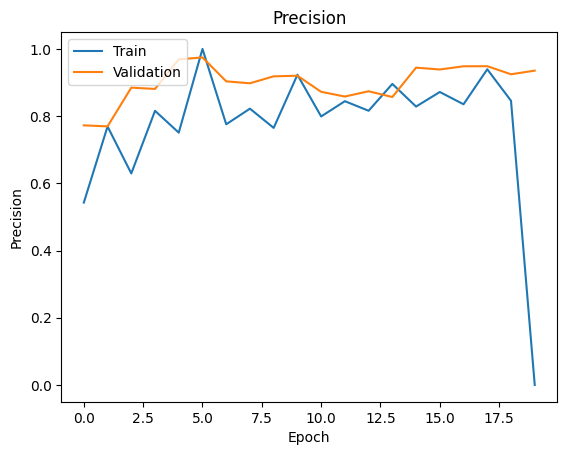

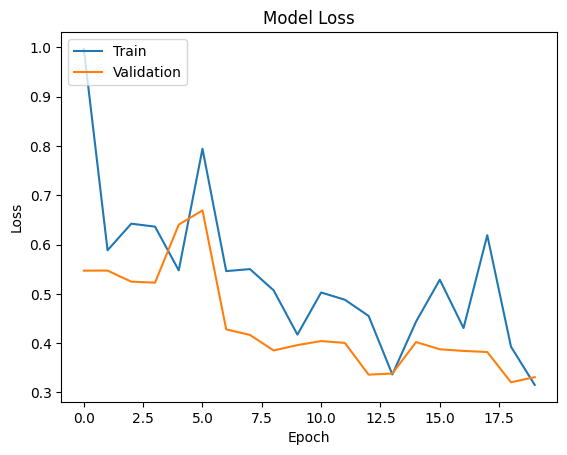

In [57]:
plt.plot(history_4.history['Precision']) #train metrics.
plt.plot(history_4.history['val_Precision']) #validation data metrics.
plt.title('Precision') #title for the plot.
plt.ylabel('Precision') #label for the y-axis.
plt.xlabel('Epoch') #label for the x-axis.
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# plot loss.
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [58]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 377ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.867336  0.854751   0.810242  0.827899


91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 380ms/step


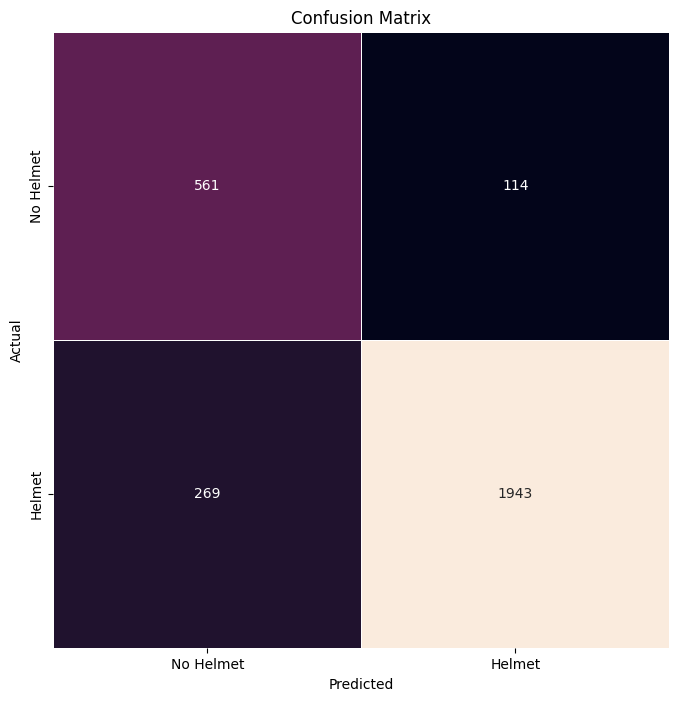

In [59]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [60]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 364ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
1  0.864297  0.841411   0.805941  0.820787


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 368ms/step


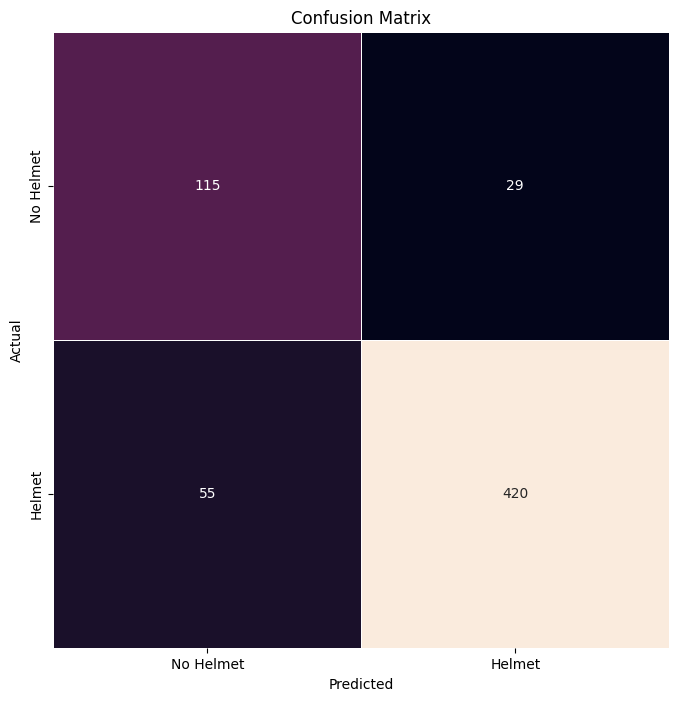

In [61]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

#### Visualizing the predictions

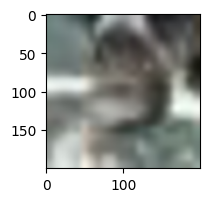

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label: 0
True Label: label    0
Name: 840, dtype: int64


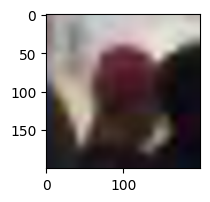

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label: 0
True Label: label    1
Name: 1133, dtype: int64


In [62]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_4.predict(X_val_normalized[12].reshape(1,200,200,3)) 
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[12] 
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33]) 
plt.show()
prediction = model_4.predict(X_val_normalized[33].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label.
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val.
true_label = y_val.iloc[33] 
print('True Label:', true_label)

# **Model Performance Comparison and Final Model Selection**

In [63]:
# Training performance comparison.

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [64]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [65]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.969519,0.924489,0.928646,0.867336
Recall,0.961579,0.942488,0.945201,0.854751
Precision,0.954177,0.878746,0.884178,0.810242
F1 Score,0.957807,0.903317,0.908179,0.827899


In [66]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.907916,0.869144,0.885299,0.864297
Recall,0.869832,0.876023,0.886550,0.841411
Precision,0.871636,0.812827,0.831378,0.805941
F1 Score,0.870728,0.834872,0.852469,0.820787


In [67]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.061603,0.055345,0.043347,0.003039
Recall,0.091747,0.066465,0.058651,0.013340
Precision,0.082541,0.065919,0.052800,0.004300
F1 Score,0.087079,0.068445,0.055710,0.007112


* The CNN had slghtly better results than the VGG-16 Models.  This could be due to using a balanced dataset with higher noise for training the VGG-16 models.
* Although the CNN shows a good generalization, Model 4 (VGG-16+FFNN+Data Aug) has the lowest difference between training and validation, making it the better model to work with unseen data (best genralization and high production environment potential), so it will be selected as best model.

In [72]:
best_model = model_4

## Test Performance

In [73]:
model_test_perf = model_performance_classification(best_model, X_test_normalized,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 363ms/step


In [74]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
1,0.864297,0.841983,0.806815,0.821535


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 364ms/step


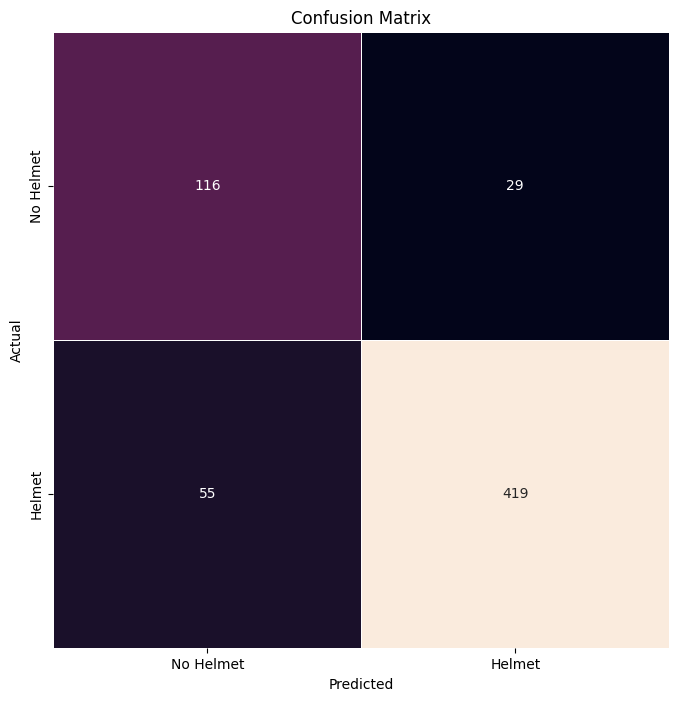

In [75]:
plot_confusion_matrix(best_model, X_test_normalized,y_test)

# **Actionable Insights & Recommendations**

### Actionable Insights

Regarding the dataset:

* The images in the dataset have been pre-processed, so initial quality is quite low.  This increase the amount of noise, loss of information and lower performance for the model with each posterior processing.
* The original labeling of the dataset doesn't follow convential practice of assigning the positive class to the target label. Although this doesn't affects the model's design, it requires to keep the focus on the "negative class" (no helmet), and choosing the right metrics.

Regarding model building:

* The dataset is imbalanced towards the "positive class" (with helmet), this will increase in the model the probality of false positives, that for safety issues, is the error needed to be minimum.
* CNN gave better metrics than the ones based on VVG-16, but it was trained with the "original imbalanced" dataset. VVG-16 models used the oversampled balanced dataset that contained more noise, and showed better performance when adding a FNN, but droped with the augmented data as it increased the level of noise, but got better generalization due to more data points.
* Although the drop in general scores compared to the 2 initial VVG-16 based models, Model 4 was selected for a good Precision score value, and the lowest diference between training and validation. 

Regarding model's performance:

* When applying the test dataset to model 4, the precision score was very close to the precision obtained for the validation data, showing good generalization and great performance on unseen data.


### Recommendations

* Depending on the type of site, SafeGuard Corp could deploy the model at entry points for temporal sites, such as construction areas, to control people entering the dangerous area, and prevent access to anybody without the basic Personal Protection Equipment (PPE); and for more permanent sites, like quarries and factories, may implement a continuos monitoring system inside the site to verify personnel is always wearing their PPE.
* As the quality of the images can have a significant impact on model performance, it is important to retrain the model using the best quality images in a 224 by 224 size, and a more balanced dataset to reduce the chance of false positives. Using a pre-trained model as VVG-16 with a FFN and increasing the data by testing different configurations for data augmentation is expected to give the best results.

<font size=5 color='blue'>Power Ahead!</font>
___

Disclaimer: this notebook uses some of the code and structure from: HelmNet_Low_Code_Notebook_v2.ipynb, CNN_Sequential_Model-1.ipynb, Hands_on_Transfer_Learning_Notebook.ipynb and Monkey_Species_Classification_Notebook_MLS_2.ipynb; and some AI generated recommendations (for code) from Goggle Colab.